In [36]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import cv2
from tensorflow.keras import regularizers
from ultralytics import YOLO
import glob

In [12]:
source_dir = "/kaggle/input/datasets/mohamedmaher5/vehicle-classification/Vehicles"  
classes = ["Cars", "Motorcycles", "Auto Rickshaws", "Bikes"]
output_dir = "data"
clean_dir = "data_clean"

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

for cls in classes:
    images = os.listdir(os.path.join(source_dir, cls))
    random.shuffle(images)
    train_end = int(len(images) * 0.7)
    val_end = int(len(images) * 0.85)

    splits = {"train": images[:train_end], "val": images[train_end:val_end], "test": images[val_end:]}
    for split, imgs in splits.items():
        for img in imgs:
            shutil.copy(os.path.join(source_dir, cls, img), os.path.join(output_dir, split, cls, img))

def convert_to_rgb(input_dir, output_dir):
    for root, _, files in os.walk(input_dir):
        for file in files:
            rel_path = os.path.relpath(root, input_dir)
            os.makedirs(os.path.join(output_dir, rel_path), exist_ok=True)
            try:
                with Image.open(os.path.join(root, file)) as img:
                    img.convert("RGB").save(os.path.join(output_dir, rel_path, file), "JPEG")
            except: continue

convert_to_rgb(output_dir, clean_dir)
print("Data Preparation Complete.")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Data Preparation Complete.


In [13]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(f"{clean_dir}/train", image_size=img_size, batch_size=batch_size)
val_ds = tf.keras.utils.image_dataset_from_directory(f"{clean_dir}/val", image_size=img_size, batch_size=batch_size)
test_ds = tf.keras.utils.image_dataset_from_directory(f"{clean_dir}/test", image_size=img_size, batch_size=batch_size, shuffle=False)

Found 2891 files belonging to 4 classes.
Found 874 files belonging to 4 classes.
Found 890 files belonging to 4 classes.


In [22]:
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax') # Must match your 4 vehicle classes
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_base = baseline_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=10
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.5189 - loss: 1.3023 - val_accuracy: 0.8158 - val_loss: 0.4656
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.8622 - loss: 0.3701 - val_accuracy: 0.9199 - val_loss: 0.2437
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.9226 - loss: 0.2128 - val_accuracy: 0.9485 - val_loss: 0.1838
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9696 - loss: 0.0875 - val_accuracy: 0.9691 - val_loss: 0.1335
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9699 - loss: 0.0839 - val_accuracy: 0.9588 - val_loss: 0.1762
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9840 - loss: 0.0384 - val_accuracy: 0.9622 - val_loss: 0.1776
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9950 - loss: 0.0169 - val_accuracy: 0.9611 - val_loss: 0.2234
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9949 - loss: 0.0105 - val_accuracy: 0.9634 - val_loss: 0

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


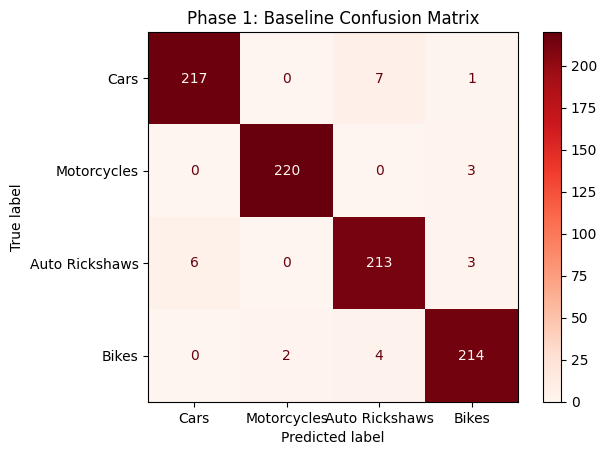

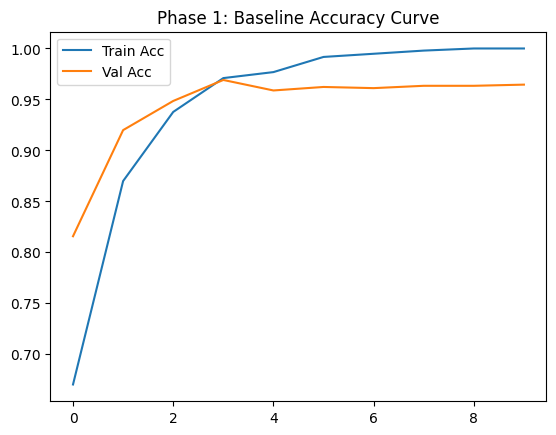

In [23]:
y_true_base = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_base = np.argmax(baseline_model.predict(test_ds), axis=1)

cm_base = confusion_matrix(y_true_base, y_pred_base)
disp_base = ConfusionMatrixDisplay(cm_base, display_labels=classes)
disp_base.plot(cmap=plt.cm.Reds)
plt.title("Phase 1: Baseline Confusion Matrix")
plt.show()

plt.plot(history_base.history['accuracy'], label='Train Acc')
plt.plot(history_base.history['val_accuracy'], label='Val Acc')
plt.title('Phase 1: Baseline Accuracy Curve')
plt.legend()
plt.show()

In [26]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), 
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False 

model_tl = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    
    layers.Dropout(0.4), 
    
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    
    layers.Dropout(0.2),
    layers.Dense(4, activation='softmax') 
])

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=4, 
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.2, 
        patience=2, 
        verbose=1
    )
]

history_tl = model_tl.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=15, 
    callbacks=callbacks
)

Epoch 1/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 14s 96ms/step - accuracy: 0.4763 - loss: 1.4676 - val_accuracy: 0.9508 - val_loss: 0.5034 - learning_rate: 1.0000e-04
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8482 - loss: 0.6519 - val_accuracy: 0.9645 - val_loss: 0.3676 - learning_rate: 1.0000e-04
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8984 - loss: 0.5010 - val_accuracy: 0.9725 - val_loss: 0.3252 - learning_rate: 1.0000e-04
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.9163 - loss: 0.4451 - val_accuracy: 0.9748 - val_loss: 0.3086 - learning_rate: 1.0000e-04
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9311 - loss: 0.4307 - val_accuracy: 0.9805 - val_loss: 0.2960 - learning_rate: 1.0000e-04
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.9314 - loss: 0.4136 - val_accuracy: 0.9828 - val_loss: 0.2853 - learning_rate: 1.0000e-04
Epoch 7/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9434

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step


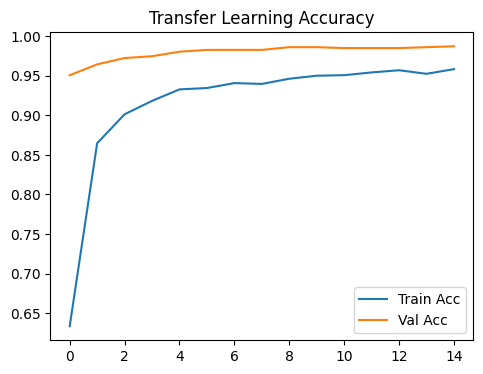

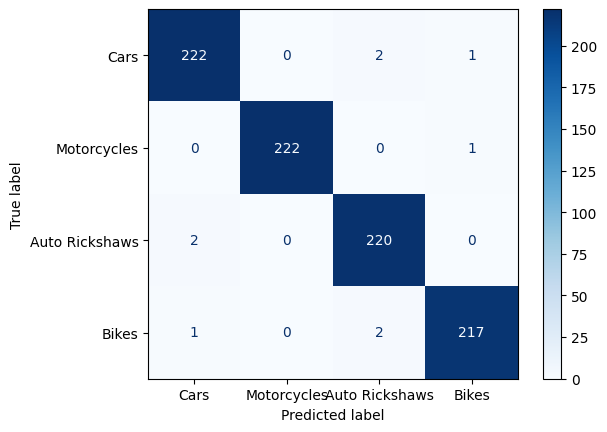

In [27]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='Train Acc')
plt.plot(history_tl.history['val_accuracy'], label='Val Acc')
plt.title('Transfer Learning Accuracy')
plt.legend()

y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model_tl.predict(test_ds), axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [38]:
import os

base_yolo_path = '/kaggle/working/data_yolo'

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(base_yolo_path, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(base_yolo_path, 'labels', split), exist_ok=True)

print(f"Directory structure created at {base_yolo_path}")

Directory structure created at /kaggle/working/data_yolo


In [42]:
base_yolo_path = '/kaggle/working/data_yolo'
src_clean_dir = "/kaggle/working/data_clean"

for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(base_yolo_path, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(base_yolo_path, 'labels', split), exist_ok=True)

for split in ['train', 'val', 'test']:
    all_images = glob.glob(os.path.join(src_clean_dir, split, "**/*.jpg"), recursive=True)
    for img_path in all_images:
        shutil.copy(img_path, os.path.join(base_yolo_path, 'images', split, os.path.basename(img_path)))


In [51]:
from ultralytics import YOLO
import os

model_auto = YOLO("yolov8n.pt") 

def auto_label_with_folder_logic(base_img_dir, base_label_dir):
    folder_to_id = {
        "Cars": 0,
        "Motorcycles": 1,
        "Auto Rickshaws": 2,
        "Bikes": 3
    }

    for split in ['train', 'val']:
        for folder_name, my_class_id in folder_to_id.items():
            img_folder = os.path.join(base_img_dir, split, folder_name)
            label_folder = os.path.join(base_label_dir, split)
            os.makedirs(label_folder, exist_ok=True)

            if not os.path.exists(img_folder): continue
            
            images = [f for f in os.listdir(img_folder) if f.endswith('.jpg')]
            for img_name in images:
                results = model_auto(os.path.join(img_folder, img_name), verbose=False)
                label_path = os.path.join(label_folder, img_name.replace('.jpg', '.txt'))
                
                with open(label_path, 'w') as f:
                    for box in results[0].boxes:

                        xywh = box.xywhn[0].tolist() 
                        f.write(f"{my_class_id} {' '.join(map(str, xywh))}\n")

auto_label_with_folder_logic('/kaggle/working/data_clean', '/kaggle/working/data_yolo/labels')

In [52]:
train_labels = os.listdir('/kaggle/working/data_yolo/labels/train')
val_labels = os.listdir('/kaggle/working/data_yolo/labels/val')
print(f"Labels found: Train={len(train_labels)}, Val={len(val_labels)}")

Labels found: Train=2811, Val=859


Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/nadinebasha/yaml-file/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Phase3_YOLO-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

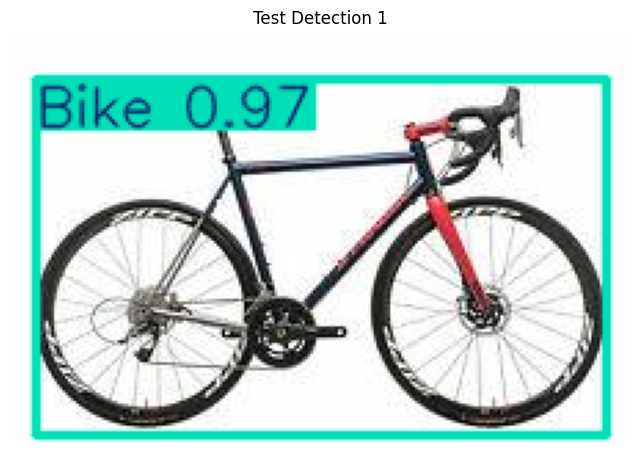


image 1/1 /kaggle/working/data_yolo/images/test/Motorcycle (50).jpg: 640x640 1 Motorcycle, 8.1ms
Speed: 2.7ms preprocess, 8.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


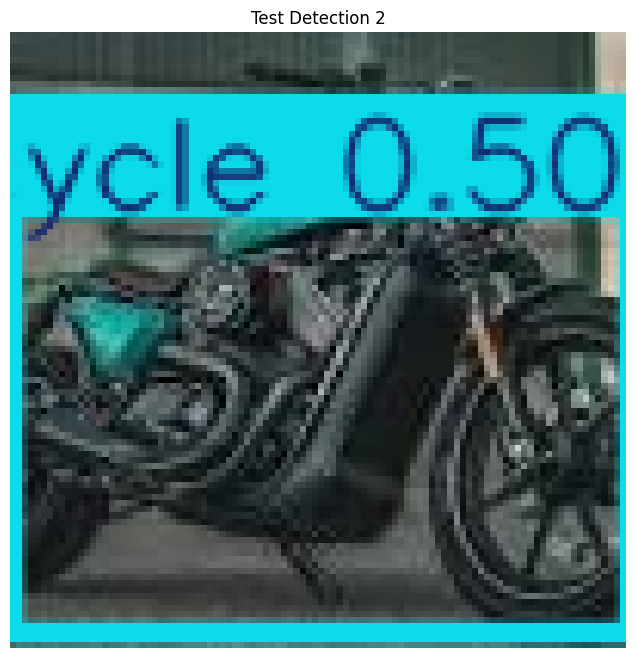


image 1/1 /kaggle/working/data_yolo/images/test/Bike (432).jpg: 448x640 1 Bike, 10.4ms
Speed: 2.0ms preprocess, 10.4ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


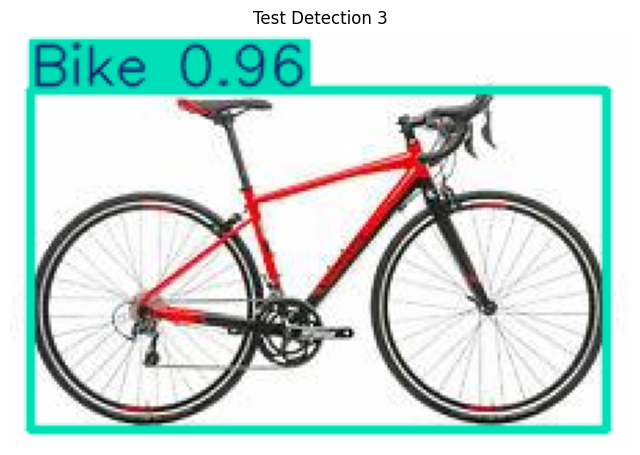


image 1/1 /kaggle/working/data_yolo/images/test/Motorcycle (199).jpg: 480x640 7 Motorcycles, 7.6ms
Speed: 2.0ms preprocess, 7.6ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


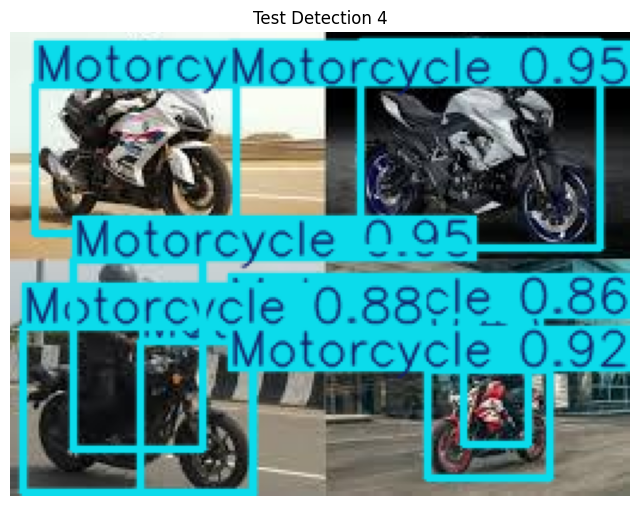


image 1/1 /kaggle/working/data_yolo/images/test/Motorcycle (624).jpg: 448x640 1 Motorcycle, 7.3ms
Speed: 2.1ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


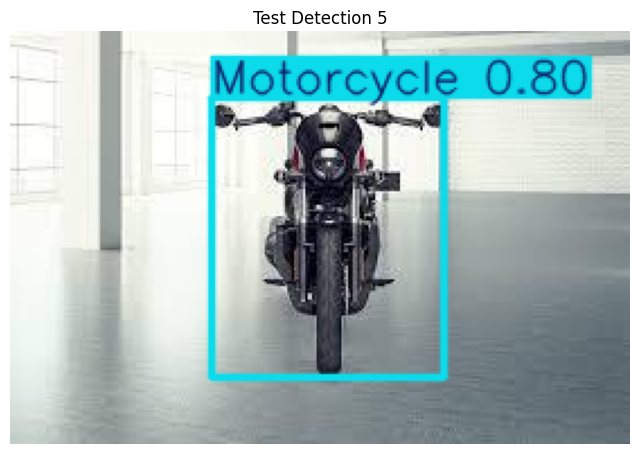


image 1/1 /kaggle/working/data_yolo/images/test/Bike (615).jpg: 512x640 1 Bike, 7.2ms
Speed: 1.7ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


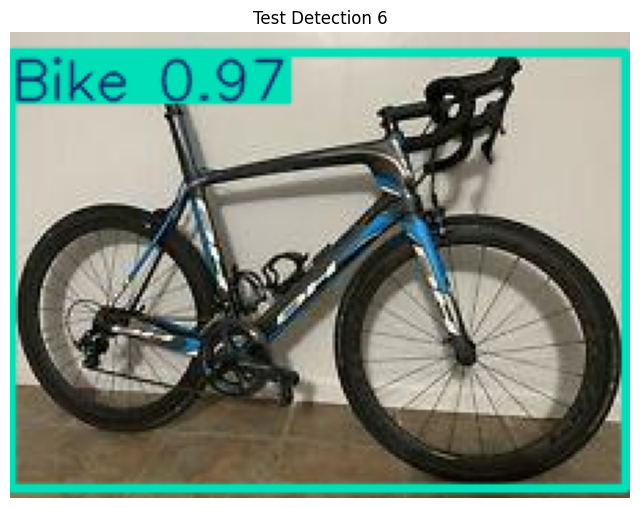


image 1/1 /kaggle/working/data_yolo/images/test/Bike (757).jpg: 640x512 2 Bikes, 8.8ms
Speed: 2.2ms preprocess, 8.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 512)


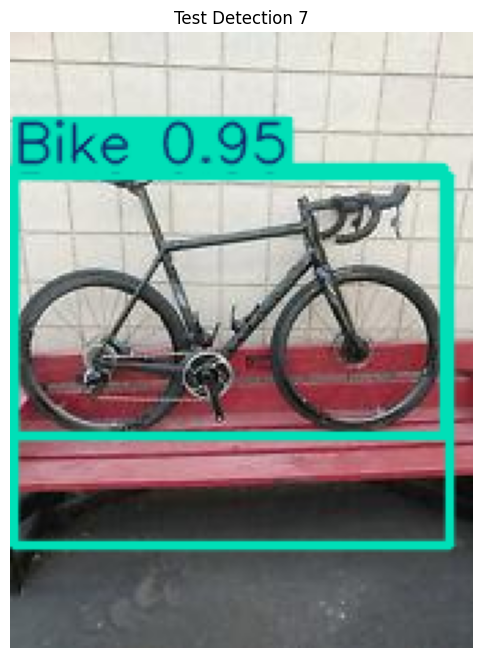


image 1/1 /kaggle/working/data_yolo/images/test/Auto Rickshaw (208).jpg: 480x640 2 Auto Rickshaws, 6.8ms
Speed: 1.7ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


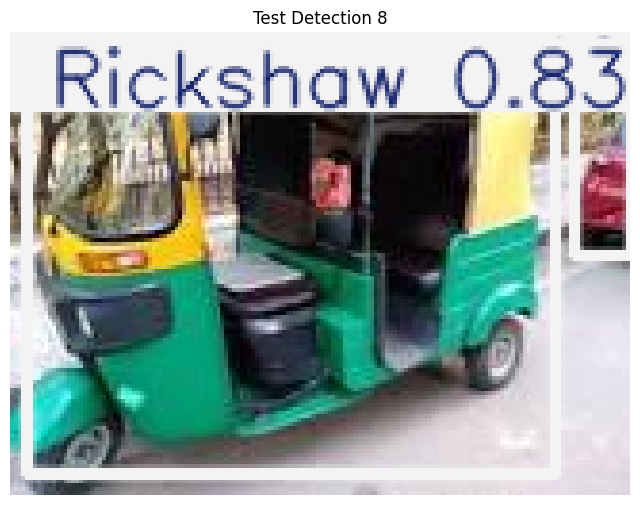


image 1/1 /kaggle/working/data_yolo/images/test/Motorcycle (538).jpg: 480x640 3 Motorcycles, 6.3ms
Speed: 2.6ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


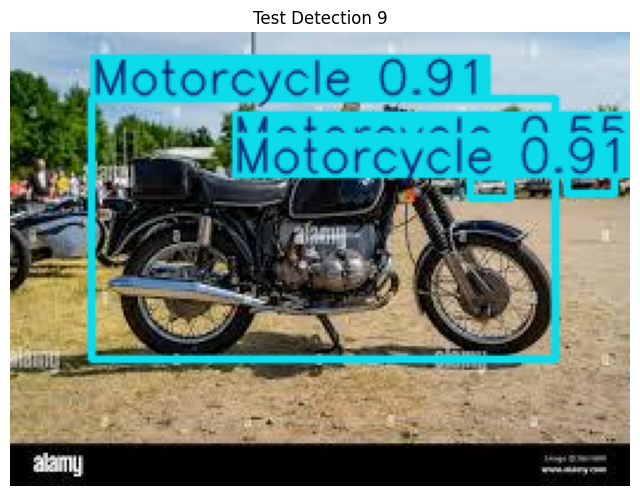


image 1/1 /kaggle/working/data_yolo/images/test/Auto Rickshaw (197).jpg: 640x480 1 Auto Rickshaw, 7.4ms
Speed: 1.7ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


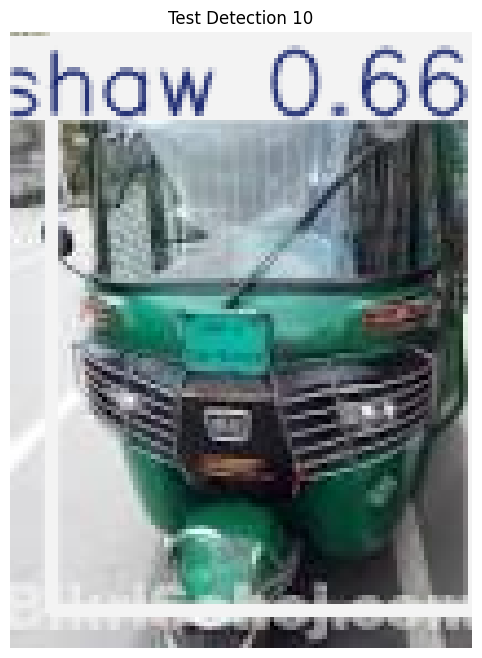


image 1/1 /kaggle/working/data_yolo/images/test/Car (514).jpg: 480x640 1 Car, 7.3ms
Speed: 1.9ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


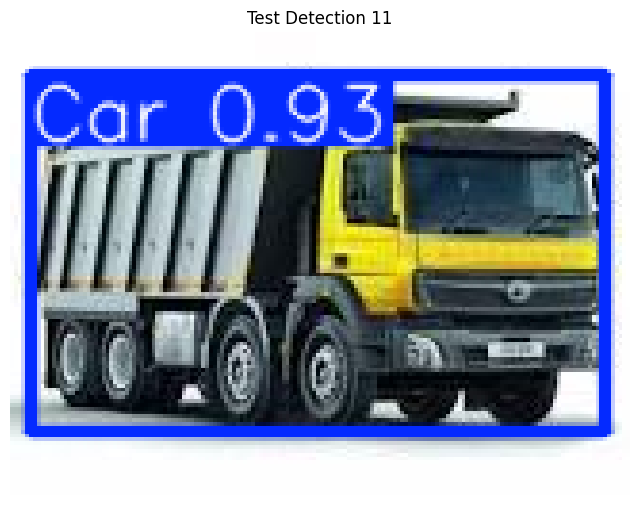


image 1/1 /kaggle/working/data_yolo/images/test/Motorcycle (452).jpg: 416x640 1 Motorcycle, 8.0ms
Speed: 1.9ms preprocess, 8.0ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)


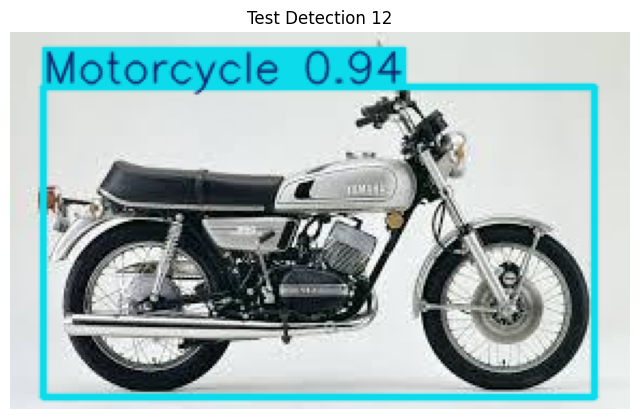


image 1/1 /kaggle/working/data_yolo/images/test/Auto Rickshaw (569).jpg: 480x640 1 Auto Rickshaw, 6.9ms
Speed: 2.0ms preprocess, 6.9ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


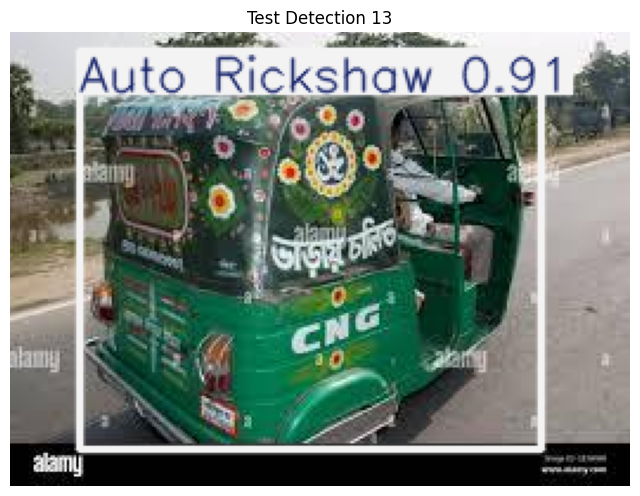


image 1/1 /kaggle/working/data_yolo/images/test/Car (239).jpg: 416x640 1 Car, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)


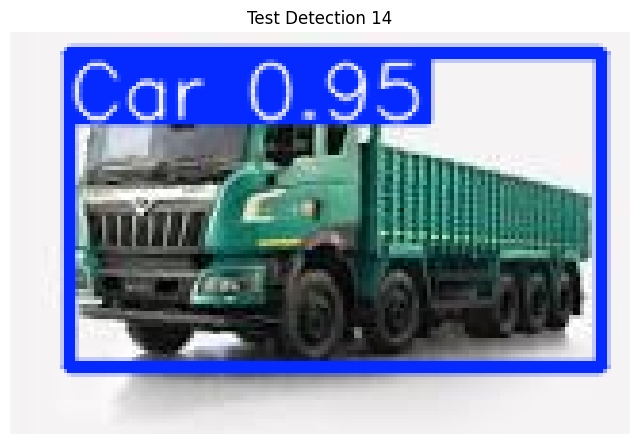


image 1/1 /kaggle/working/data_yolo/images/test/Car (364).jpg: 448x640 1 Car, 7.0ms
Speed: 1.6ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


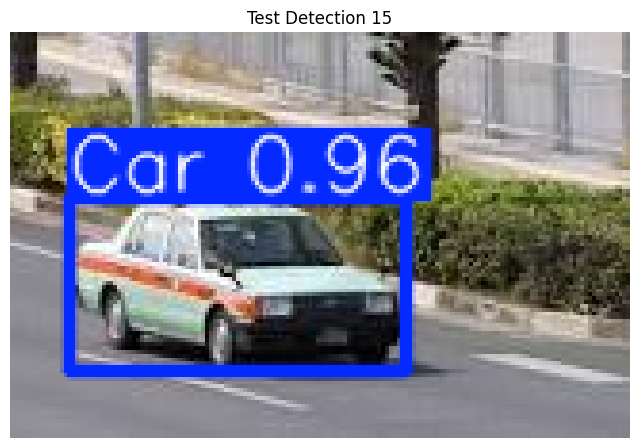


image 1/1 /kaggle/working/data_yolo/images/test/Motorcycle (672).jpg: 352x640 1 Motorcycle, 7.5ms
Speed: 1.4ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 352, 640)


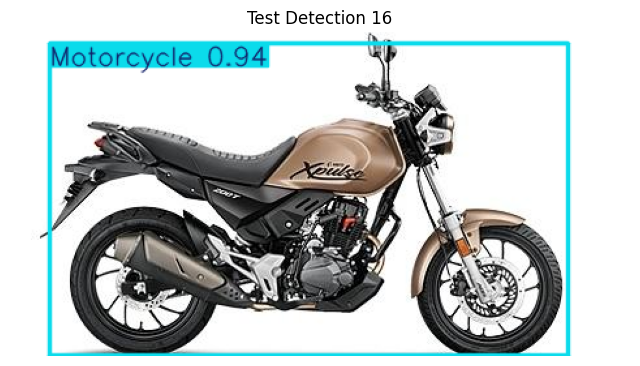


image 1/1 /kaggle/working/data_yolo/images/test/Auto Rickshaw (664).jpg: 384x640 2 Auto Rickshaws, 7.4ms
Speed: 2.1ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


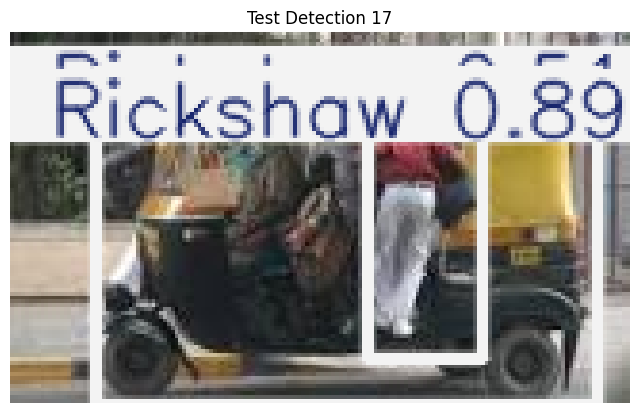


image 1/1 /kaggle/working/data_yolo/images/test/Bike (193).jpg: 512x640 1 Bike, 7.0ms
Speed: 1.8ms preprocess, 7.0ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


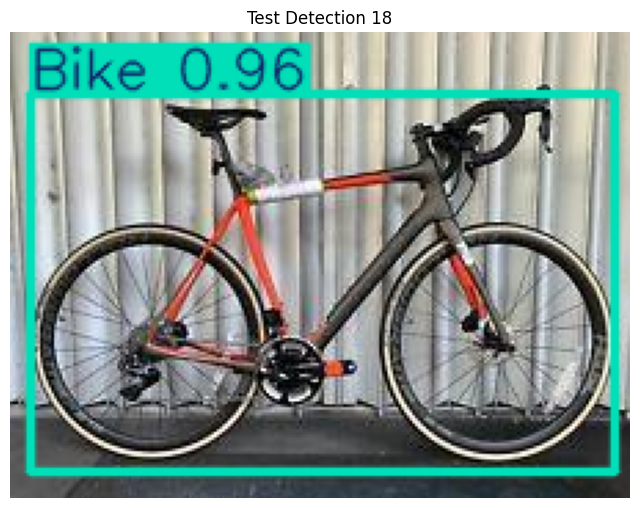


image 1/1 /kaggle/working/data_yolo/images/test/Car (59).jpg: 448x640 1 Car, 7.3ms
Speed: 2.2ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)


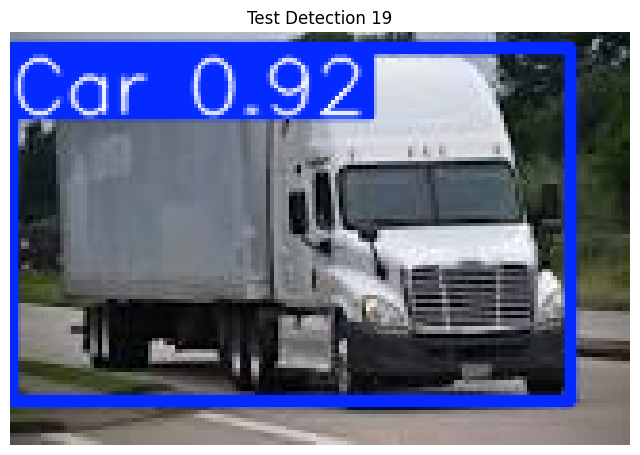


image 1/1 /kaggle/working/data_yolo/images/test/Bike (281).jpg: 512x640 1 Bike, 6.7ms
Speed: 1.7ms preprocess, 6.7ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


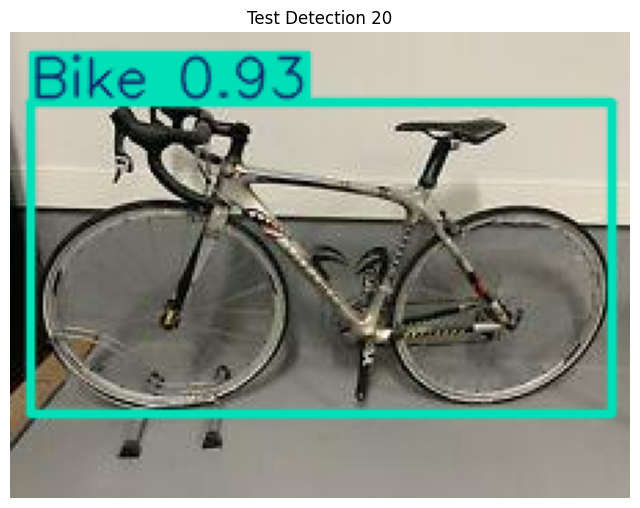

In [53]:
model_yolo = YOLO("yolov8n.pt") 


results = model_yolo.train(
    data="/kaggle/input/datasets/nadinebasha/yaml-file/data.yaml", 
    epochs=15, 
    imgsz=640, 
    batch=16,
    project="Vehicle_Detection",
    name="Phase3_YOLO"
)


metrics = model_yolo.val()

print(f"--- Phase 3 Evaluation Metrics ---")
print(f"mAP (50-95): {metrics.box.map}")
print(f"mAP (50): {metrics.box.map50}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")


test_images = glob.glob("/kaggle/working/data_yolo/images/test/*.jpg")[:20]

for i, img_path in enumerate(test_images):
    res = model_yolo.predict(img_path, conf=0.4)
    
    res_plotted = res[0].plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Test Detection {i+1}")
    plt.axis("off")
    plt.show()

In [54]:
metrics = model_yolo.val()

print(f"Mean Average Precision (mAP50): {metrics.box.map50}")
print(f"Precision: {metrics.box.mp}")
print(f"Recall: {metrics.box.mr}")

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 515.8±421.9 MB/s, size: 27.8 KB)
val: Scanning /kaggle/working/data_yolo/labels/val.cache... 859 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 859/859 300.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 54/54 8.6it/s 6.3s0.2ss
                   all        859       1469      0.891      0.737      0.829      0.712
                   Car        210        373      0.912      0.747      0.819      0.737
            Motorcycle        202        325      0.896       0.77      0.859      0.723
         Auto Rickshaw        190        495      0.816      0.663      0.748      0.602
                  Bike        209        276      0.938      0.769      0.889      0.788
Speed: 0.7ms preprocess, 2.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/r

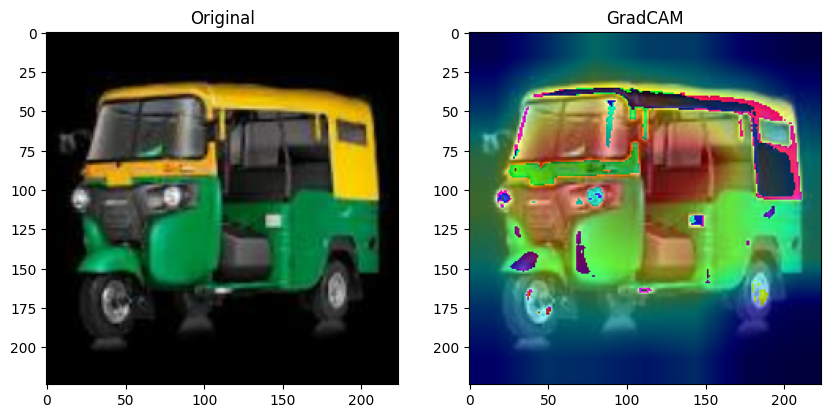

In [29]:
def compute_gradcam(model, img_batch, backbone_name, internal_layer_name):
    backbone = model.get_layer(backbone_name)
    

    grad_model = tf.keras.models.Model(
        [backbone.input], 
        [backbone.get_layer(internal_layer_name).output, backbone.output]
    )


    img_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(img_batch)

    with tf.GradientTape() as tape:
        conv_outputs, last_layer_output = grad_model(img_preprocessed)
        loss = tf.reduce_max(last_layer_output, axis=-1)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()


backbone_name = 'mobilenetv2_1.00_224'
internal_layer = 'out_relu' 

for images, labels in test_ds.take(1):
    img_tensor = images[0:1] 
    original_img = images[0].numpy().astype("uint8")
    
    heatmap = compute_gradcam(model_tl, img_tensor, backbone_name, internal_layer)
    
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed = heatmap_colored * 0.4 + original_img
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(original_img); plt.title("Original")
    plt.subplot(1, 2, 2); plt.imshow(superimposed.astype("uint8")); plt.title("GradCAM")
    plt.show()
    break

I0000 00:00:1777807060.096988      57 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x21451580


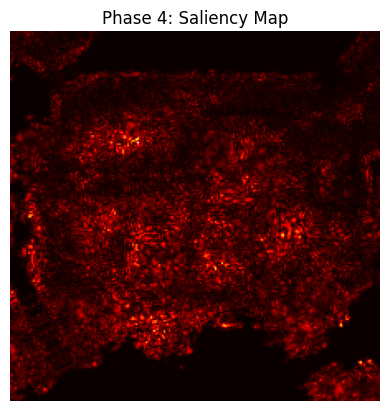

In [30]:
def get_saliency_map(model, img_batch):
    img_tensor = tf.convert_to_tensor(img_batch)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        predictions = model(img_tensor)
        top_class_idx = tf.argmax(predictions[0])
        loss = predictions[:, top_class_idx]
    
    grads = tape.gradient(loss, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)
    return saliency[0].numpy()

saliency = get_saliency_map(model_tl, img_tensor)
plt.imshow(saliency, cmap='hot')
plt.title("Phase 4: Saliency Map")
plt.axis("off")
plt.show()